# 04 — Normalization Basics

## Why normalize?

Our dataset has four columns with very different scales:

| Column | Typical range |
|--------|---------------|
| `student_score` | 20 – 100 |
| `temperature` | 5 – 40 |
| `sales` | 100 – 900 |
| `stock_price` | 50 – 300 |

If we feed raw features to a machine learning model, the model may treat
**larger-magnitude features as more important** — even if that's just an
accident of units.

Normalization **removes the scale** without removing the information.

## Two core ideas

1. **Centering** — subtract the mean so the distribution is centred at zero.
2. **Scaling** — divide by a measure of spread so all features have comparable magnitude.

$$x_{\text{norm}} = \frac{x - \text{center}}{\text{scale}}$$

Different choices of *center* and *scale* give different normalization methods.

---

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
from utils.ml_utils import calculate_mean, calculate_std, z_score_normalize
from utils.plotting import plot_normalization_comparison, plot_before_after_distribution, plot_boxplot

In [2]:
df = pd.read_csv('../data/fundamentals_data.csv')
df.describe().round(2)

,student_score,temperature,sales,stock_price
count,50.00,50.00,50.00,50.00
mean,69.30,22.10,495.34,152.52
std,11.21,4.37,121.80,26.81
min,48.50,8.90,270.00,104.55
25%,61.68,19.52,394.25,127.68
50%,69.20,22.20,502.00,155.81
75%,76.02,24.98,561.50,167.70
max,94.20,29.80,796.00,231.61


## Step 1 — The problem: incomparable scales

Notice `sales` ranges from 100–900 while `temperature` only goes 5–40.
A box plot makes this stark.

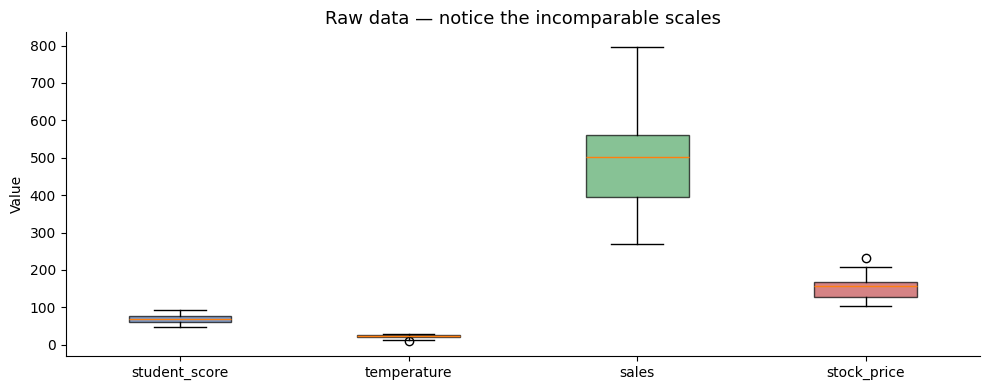

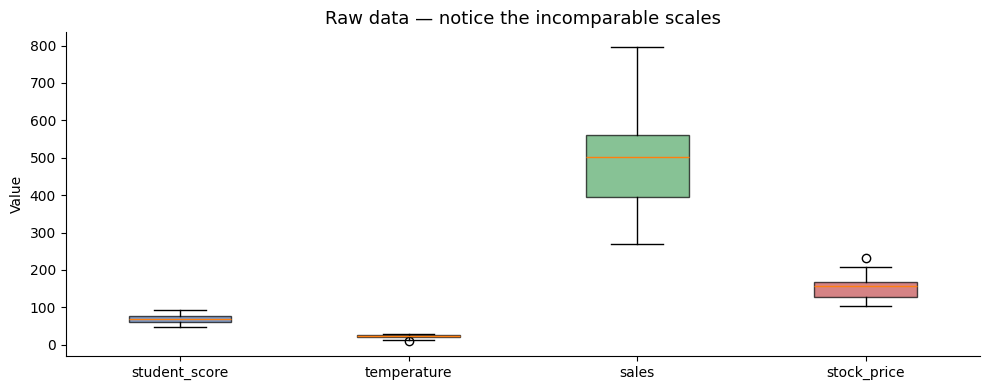

In [3]:
raw_dict = {col: df[col].values for col in df.columns}
plot_boxplot(raw_dict, title='Raw data — notice the incomparable scales', ylabel='Value')

## Step 2 — Centering only (subtract mean)

After centering, every column has mean = 0, but the **spread still differs**.

Means after centering:
student_score   -0.0
temperature      0.0
sales            0.0
stock_price      0.0
dtype: float64


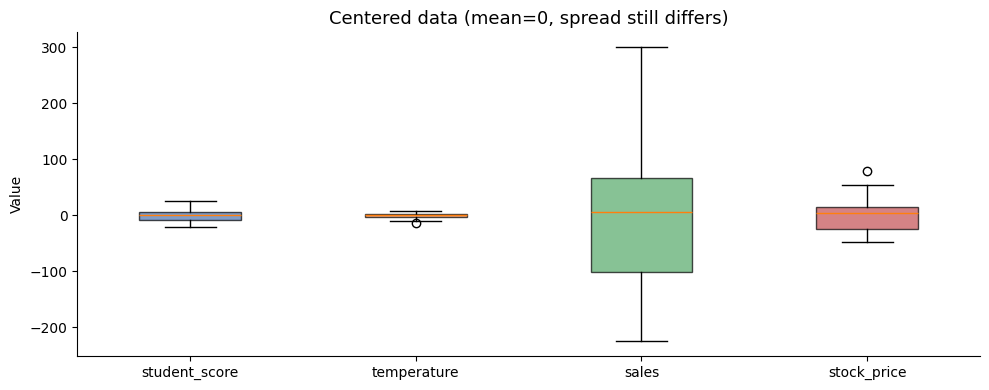

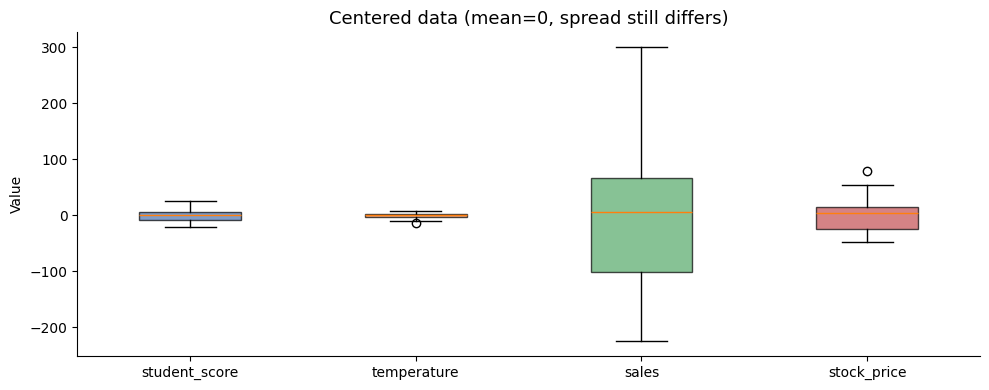

In [4]:
df_centered = df.apply(lambda col: col - col.mean())
print('Means after centering:')
print(df_centered.mean().round(6))

centered_dict = {col: df_centered[col].values for col in df_centered.columns}
plot_boxplot(centered_dict, title='Centered data (mean=0, spread still differs)', ylabel='Value')

## Step 3 — Centering + Scaling (z-score)

Dividing by the standard deviation brings every column to roughly ±1–3 range.

After z-score normalization:
       student_score  temperature   sales  stock_price
count         50.000       50.000  50.000       50.000
mean          -0.000        0.000   0.000        0.000
std            1.000        1.000   1.000        1.000
min           -1.856       -3.019  -1.850       -1.789
25%           -0.680       -0.588  -0.830       -0.926
50%           -0.009        0.024   0.055        0.123
75%            0.600        0.659   0.543        0.566
max            2.222        1.763   2.468        2.950


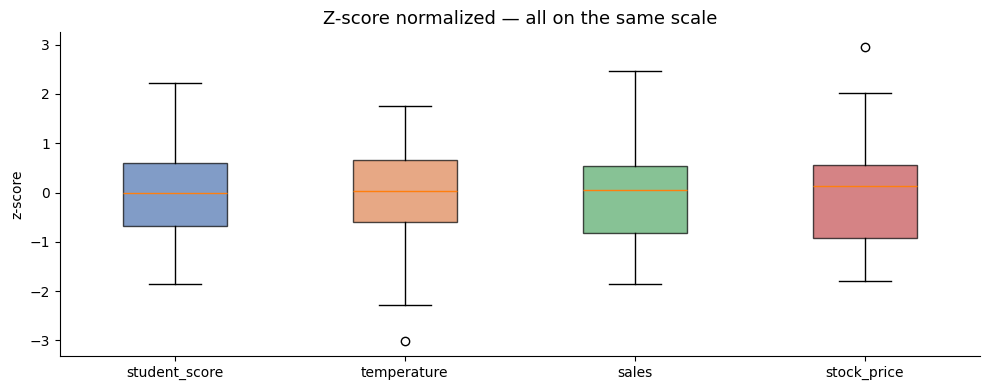

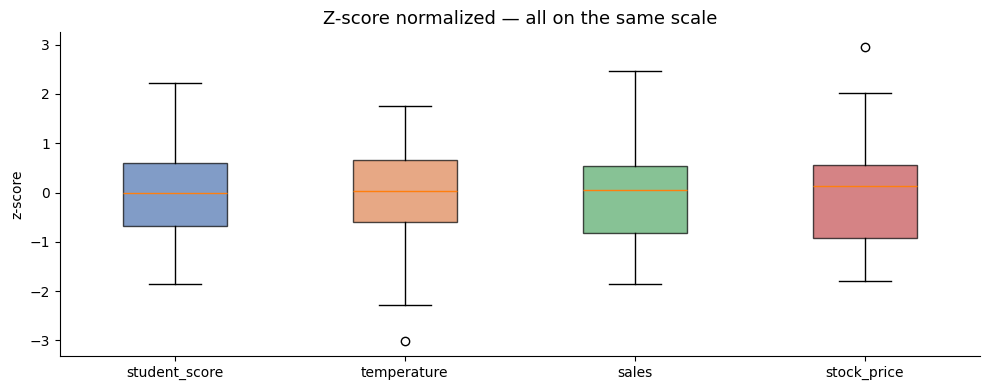

In [5]:
df_norm = df.apply(lambda col: (col - col.mean()) / col.std())
print('After z-score normalization:')
print(df_norm.describe().round(3))

norm_dict = {col: df_norm[col].values for col in df_norm.columns}
plot_boxplot(norm_dict, title='Z-score normalized — all on the same scale', ylabel='z-score')

## Step 4 — Before vs After for one column

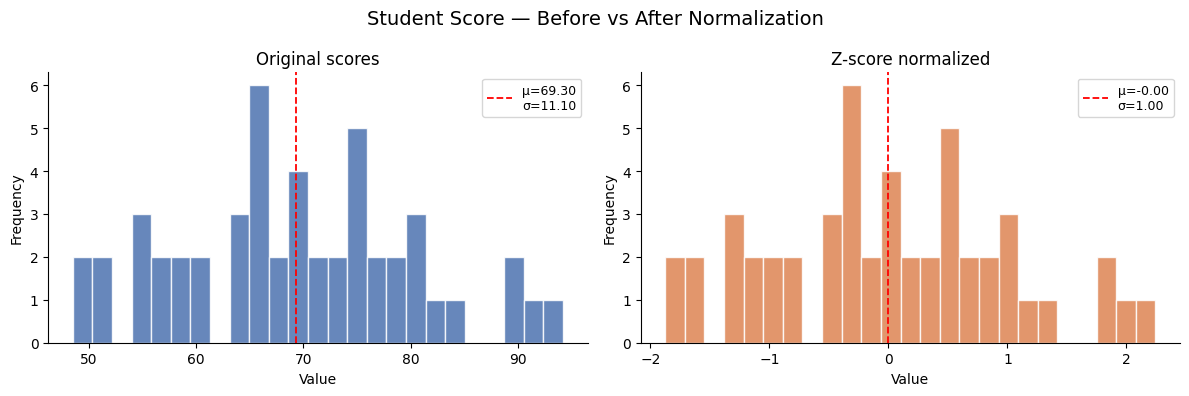

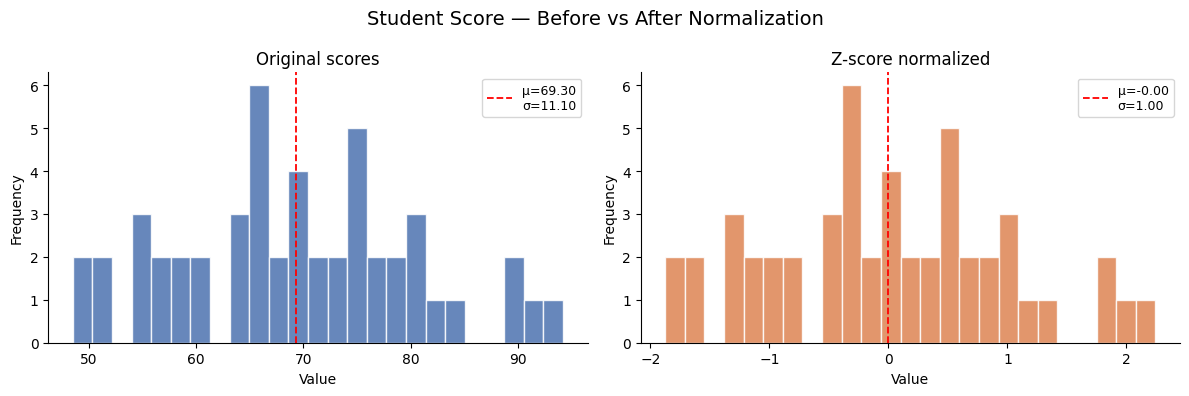

In [7]:
scores      = df['student_score'].values
scores_norm, params = z_score_normalize(scores)

plot_before_after_distribution(
    scores, scores_norm,
    label_before='Original scores',
    label_after='Z-score normalized',
    title='Student Score — Before vs After Normalization'
)

Key observation: **the shape is identical** — normalization only changes scale,
not the underlying distribution.

---
## Exercises

1. Normalize `sales` with z-score and verify mean ≈ 0, std ≈ 1.
2. What would centering-only look like for `stock_price`? Why is the spread still problematic?
3. Can you think of a case where normalization might **hurt** model performance?
   (Hint: think about tree-based models vs gradient descent models.)

---
**Next →** `05_zscore_and_scaling.ipynb` — z-score vs min-max in depth.